
--- Training CNN ---
Epoch 1/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7476 - loss: 0.5163 - val_accuracy: 0.8812 - val_loss: 0.2881
Epoch 2/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9069 - loss: 0.2361 - val_accuracy: 0.9272 - val_loss: 0.1981
Epoch 3/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9278 - loss: 0.1885 - val_accuracy: 0.9373 - val_loss: 0.1692
Epoch 4/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9372 - loss: 0.1694 - val_accuracy: 0.9411 - val_loss: 0.1574
Epoch 5/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9429 - loss: 0.1589 - val_accuracy: 0.9484 - val_loss: 0.1467
Epoch 6/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9447 - loss: 0.1516 - val_accuracy: 0.9496 - val_loss: 0.1406
Epoch 7/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9474 - loss: 0.1462 - val_accuracy: 0.9509 - val_loss: 0.1352
Epoch 8/20
329/329 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9504 - l

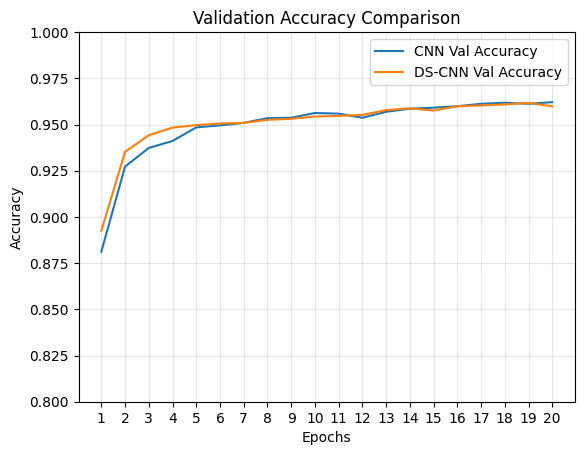

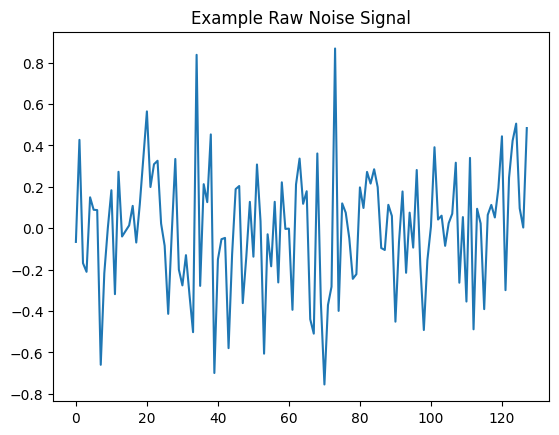

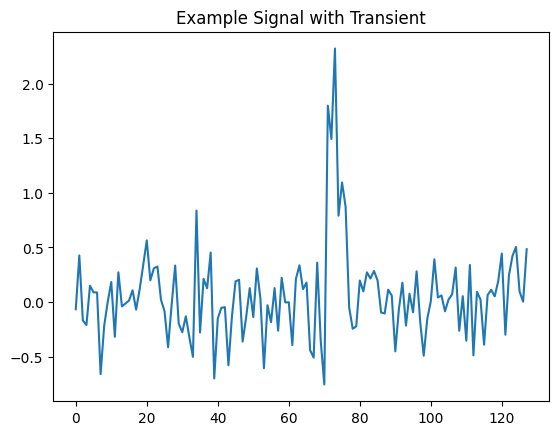

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# =========================================================
# 1. Base signal generation (paired noise)
# =========================================================

def generate_base_signals(N, n=128):
    signals = []
    for _ in range(N):
        noise_std = np.random.uniform(0.22, 0.40)
        base = np.random.normal(0, noise_std, n)
        signals.append(base)
    return np.array(signals)


def add_transient(x):
    x = x.copy()

    pos = np.random.randint(20, 110)
    amp = np.random.uniform(0.9, 2.2)

    if np.random.rand() < 0.10:
        amp *= 0.75

    width = np.random.randint(3, 7)
    shape = np.exp(-np.linspace(0, 1.0, width))

    x[pos:pos+width] += amp * shape
    return x


# =========================================================
# 2. Dataset
# =========================================================

N = 30000
base_signals = generate_base_signals(N)

X_raw = []
y = []

for base in base_signals:
    sig0 = base
    sig1 = add_transient(base)

    X_raw.append(sig0)
    y.append(0)

    X_raw.append(sig1)
    y.append(1)

X_raw = np.array(X_raw)
y = np.array(y)

X_raw = X_raw[..., np.newaxis]


# =========================================================
# 3. Train / Val / Test split
# =========================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


# =========================================================
# 4. CNN (standard)
# =========================================================

cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 1)),
    tf.keras.layers.Conv1D(8, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(16, 5, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

cnn.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])


# =========================================================
# 5. DS-CNN (Depthwise Separable CNN)
# =========================================================

from tensorflow.keras.layers import SeparableConv1D

dscnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 1)),
    SeparableConv1D(8, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    SeparableConv1D(16, 5, activation='relu'),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

dscnn.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# =========================================================
# 6. Train
# =========================================================

print("\n--- Training CNN ---")
hist_cnn = cnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)

print("\n--- Training DS-CNN ---")
hist_dscnn = dscnn.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val),
    verbose=1
)


# =========================================================
# 7. Evaluate
# =========================================================

cnn_loss, cnn_acc = cnn.evaluate(X_test, y_test, verbose=0)
dscnn_loss, dscnn_acc = dscnn.evaluate(X_test, y_test, verbose=0)

print("\nFINAL RESULTS")
print("---------------------")
print("CNN   :", cnn_acc)
print("DS-CNN:", dscnn_acc)


# =========================================================
# 8. Plot validation accuracy
# =========================================================

epochs = np.arange(1, len(hist_cnn.history['val_accuracy']) + 1)

plt.figure()
plt.plot(epochs, hist_cnn.history['val_accuracy'], label='CNN Val Accuracy')
plt.plot(epochs, hist_dscnn.history['val_accuracy'], label='DS-CNN Val Accuracy')

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.xticks(epochs)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# =========================================================
# 9. Example waveforms
# =========================================================

idx = np.random.randint(0, len(X_test))
clean = X_test[idx].squeeze()

plt.figure()
plt.plot(clean)
plt.title("Example Raw Noise Signal")
plt.show()


noisy = add_transient(clean)

plt.figure()
plt.plot(noisy)
plt.title("Example Signal with Transient")
plt.show()